# Exploring the CORD-19 Metadata

This notebook explores a subset of the **CORD-19 dataset**.  
We will perform data cleaning, preparation, analysis, and visualization to understand trends in COVID-19 research.

**Goals:**
- Inspect dataset structure and missing values  
- Clean and prepare data for analysis  
- Explore publication trends over time  
- Identify top journals and sources  
- Analyze frequent words in paper titles (table, bar chart, word cloud)



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cord_uid          4000 non-null   object 
 1   sha               3852 non-null   object 
 2   source_x          4000 non-null   object 
 3   title             4000 non-null   object 
 4   doi               4000 non-null   object 
 5   pmcid             4000 non-null   object 
 6   pubmed_id         4000 non-null   int64  
 7   license           4000 non-null   object 
 8   abstract          3835 non-null   object 
 9   publish_time      4000 non-null   object 
 10  authors           3948 non-null   object 
 11  journal           3976 non-null   object 
 12  mag_id            0 non-null      float64
 13  who_covidence_id  0 non-null      float64
 14  arxiv_id          0 non-null      float64
 15  pdf_json_files    3852 non-null   object 
 16  pmc_json_files    3881 non-null   o

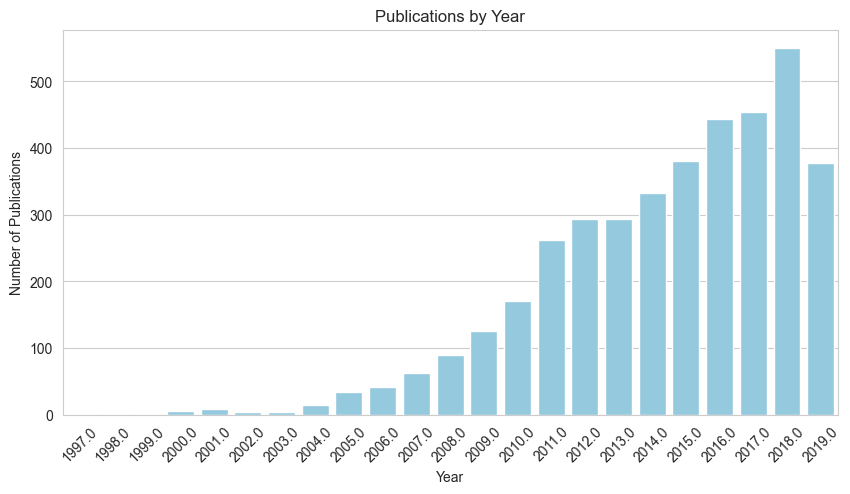

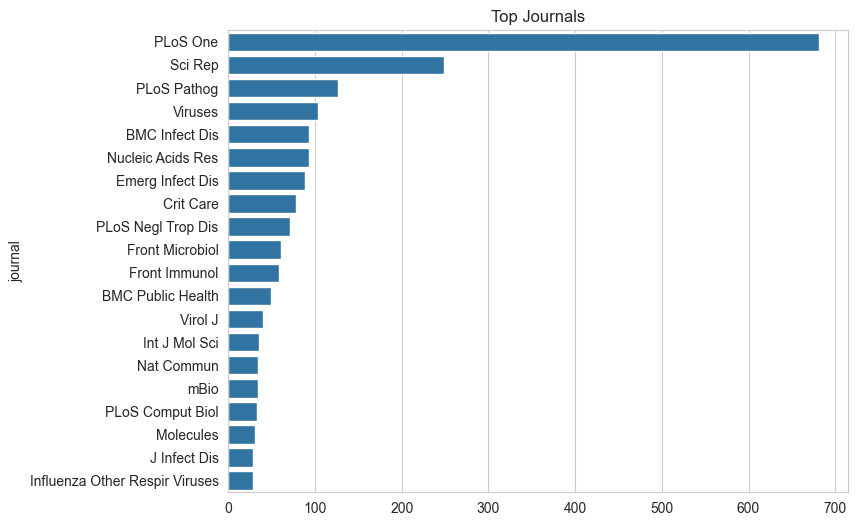

Top 25 Frequent Words in Titles:


,Word,Count
0,virus,726
1,influenza,535
2,infection,356
3,human,304
4,respiratory,246
5,cells,222
6,protein,207
7,disease,204
8,analysis,188
9,viral,188


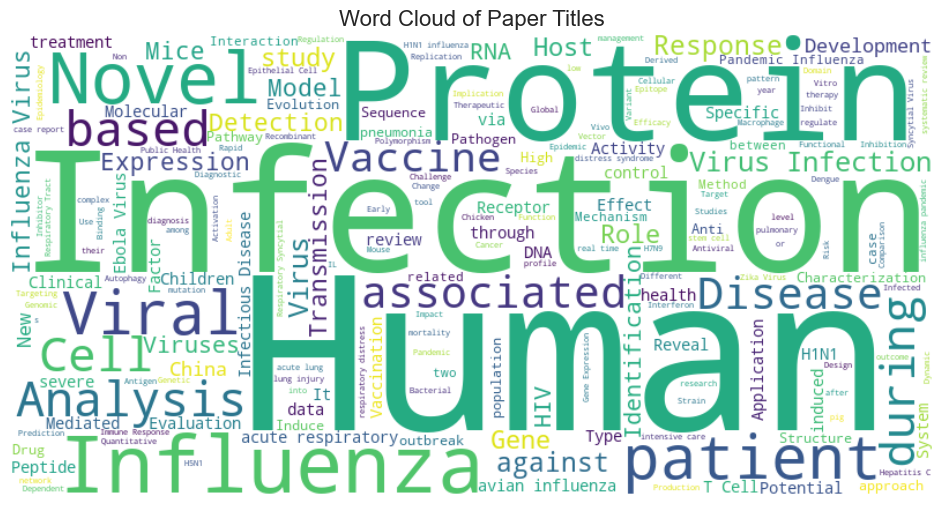

C:\Users\user\AppData\Local\Temp\ipykernel_8340\294584859.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=source_counts.index, x=source_counts.values, palette="magma")


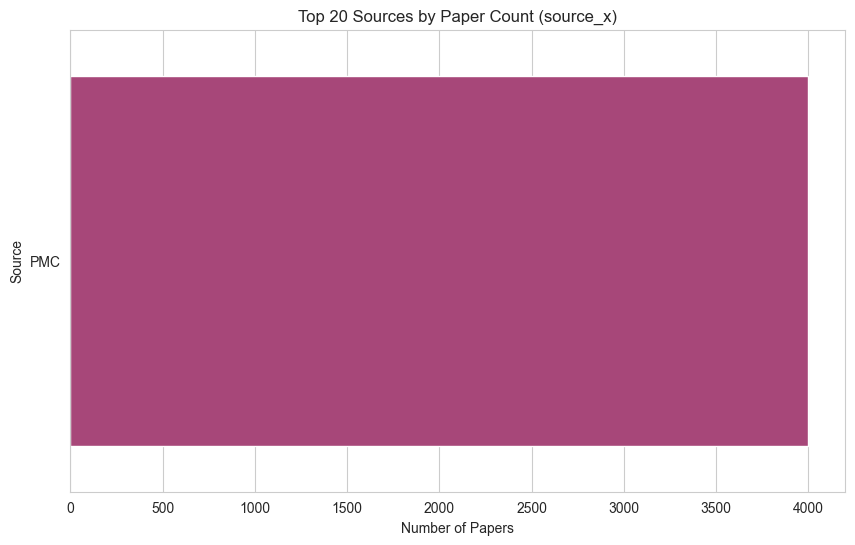

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter
from wordcloud import WordCloud

# Load the dataset
df = pd.read_csv('metadata.csv')

#Basic information about the dataset
print("\nInfo:")
print(df.info())

print("\nHead:")
print(df.head())

print("Shape:", df.shape)

# Show statistics for numerical columns
print("\nSummary statistics:")
df.describe(include=[np.number]).T

# Count missing values per column
print("\nMissing values per column:")
print(df.isnull().sum().head(20))


#Clean data
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df['year'] = df['publish_time'].dt.year
df['title'] = df['title'].fillna('').astype(str)
df['abstract'] = df['abstract'].fillna('').astype(str)
df['abstract_word_count'] = df['abstract'].str.split().apply(len)

#Simple visualizations
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

#Publications by year
# Count number of publications per year
year_counts = df['year'].value_counts().sort_index()

# Plot publications per year
plt.figure(figsize=(10, 5))
sns.barplot(x=year_counts.index, y=year_counts.values, color="skyblue")
plt.xticks(rotation=45)
plt.title("Publications by Year")
plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.show()


#Top journals publishing CORD-19 research
if 'journal' in df.columns:
    top_journals = df['journal'].value_counts().head(20)
    plt.figure(figsize=(8,6))
    sns.barplot(y=top_journals.index, x=top_journals.values)
    plt.title("Top Journals")
    plt.show()

 

# --- Word Frequency Analysis ---
stopwords = set([
    'the','and','of','in','to','for','a','on','with','by','an',
    'from','using','is','are','as','at','that','this','be','we','our'
])

words = Counter()
for title in df['title'].dropna():
    tokens = re.sub(r'[^a-zA-Z0-9\s]', '', title.lower()).split()
    for w in tokens:
        if w not in stopwords and len(w) > 1 and not w.isdigit():
            words[w] += 1

# Convert to DataFrame
words_df = pd.DataFrame(words.most_common(25), columns=["Word", "Count"])

# Display as a table
print("Top 25 Frequent Words in Titles:")
display(words_df)

# --- Word Cloud Visualization ---
text = " ".join(df['title'].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Paper Titles", fontsize=16)
plt.show()




# Distribution of paper counts by source
# Some datasets have 'source_x', others use 'journal'
if 'source_x' in df.columns:
    source_col = 'source_x'
elif 'journal' in df.columns:
    source_col = 'journal'
else:
    source_col = None

if source_col:
    # Count number of papers per source
    source_counts = df[source_col].value_counts().head(25)

    # Plot top 20 sources
    plt.figure(figsize=(10, 6))
    sns.barplot(y=source_counts.index, x=source_counts.values, palette="magma")
    plt.title(f"Top 20 Sources by Paper Count ({source_col})")
    plt.xlabel("Number of Papers")
    plt.ylabel("Source")
    plt.show()
else:
    print("No 'source_x' or 'journal' column found in this dataset.")










